# Geodesic Spectral-Generalised Least Squares (GS-GLS) Demo

This notebook demonstrates the implementation of the **GS-GLS** framework for optimal reconciliation of hierarchical time series. 

## Theoretical Background

We address the problem of reconciling base forecasts $\hat{y}$ to satisfy aggregation constraints $y = S b$.
The MinT estimator is given by:
$$
\tilde{y} = S (S' W^{-1} S)^{-1} S' W^{-1} \hat{y}
$$
where $W$ is the error covariance matrix.

**GS-GLS Innovation**:
We model $W = \Sigma_{tm} \otimes \Sigma_{sp}$ using:
1. **Spectral Temporal Precision**: $\Sigma_{tm}^{-1} \approx F^* \Lambda^{-1} F$ where $\Lambda \approx 2\pi f(\omega)$.
2. **Geodesic Spatial Precision**: $Q_{sp} \approx \lambda (D-A) + \gamma I$ based on Matérn kernels on the hierarchy graph.


In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from hierarchy import Hierarchy
from data_generator import HierarchicalDataGenerator
from gs_gls import GSGLS

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Hierarchy Construction

We define a synthetic hierarchy: **Root -> 3 Regions -> 3 Stores per Region (9 total)**.

Total nodes: 13, Bottom nodes: 9


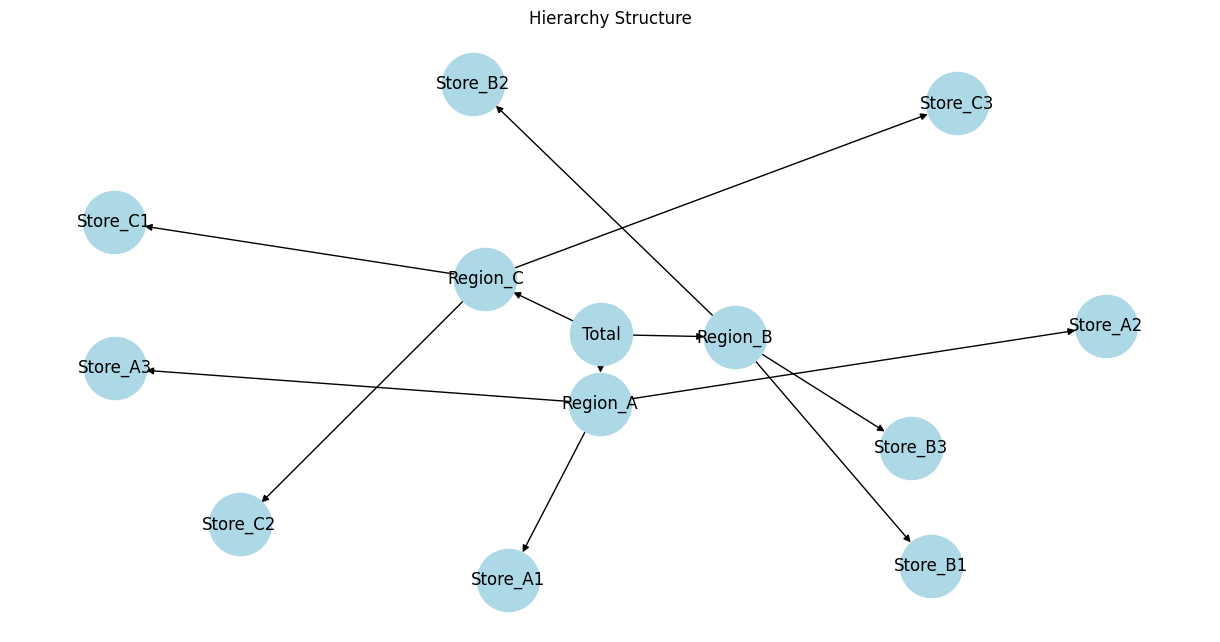

In [4]:
# Define structure: Parent -> [Children]
structure = {
    'Total': ['Region_A', 'Region_B', 'Region_C'],
    'Region_A': ['Store_A1', 'Store_A2', 'Store_A3'],
    'Region_B': ['Store_B1', 'Store_B2', 'Store_B3'],
    'Region_C': ['Store_C1', 'Store_C2', 'Store_C3']
}

h = Hierarchy(structure)
print(f"Total nodes: {h.n_nodes}, Bottom nodes: {h.m_bottom}")

# Visualize Graph
pos = nx.spring_layout(h.graph)
nx.draw(h.graph, pos, with_labels=True, node_color='lightblue', node_size=2000, arrows=True)
plt.title("Hierarchy Structure")
plt.show()

## 2. Synthetic Data Generation

We generate ground truth data $Y$ that is coherent by construction. Then we add noise to create incoherent base forecasts $\hat{Y}$.

The noise $\varepsilon$ is generated with spatiotemporal correlation:
- **Spatial**: Matérn kernel on the tree distance.
- **Temporal**: AR(1) process.

In [5]:
n_timesteps = 200
gen = HierarchicalDataGenerator(h, n_timesteps)

# Generate Ground Truth
Y_true = gen.generate_ground_truth(trend_slope=0.05, seasonal_amp=5.0)

# Generate Noise (Base Forecast Errors)
# Correlated noise! High spatial rho means regions fluctuate together.
noise = gen.generate_spatiotemporal_noise(spatial_rho=2.0, temporal_ar_coefs=[0.7], noise_scale=5.0)

Y_hat = Y_true + noise  # Incoherent Base Forecasts

print("Data Generated.")

Data Generated.


### Visualize Incoherence
Let's check if the sum of bottom nodes matches the Top node in the Base Forecasts.

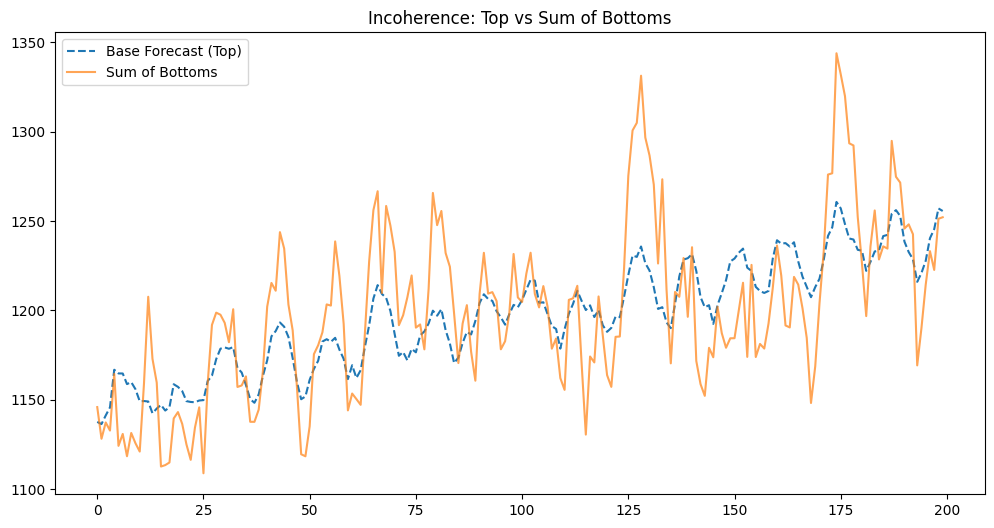

In [6]:
S = h.get_summing_matrix()
bottom_indices = [h.node_to_idx[n] for n in h.bottom_nodes]
top_idx = h.node_to_idx['Total']

Y_hat_bottom = Y_hat[bottom_indices, :]
Y_hat_sum = np.sum(Y_hat_bottom, axis=0)
Y_hat_top = Y_hat[top_idx, :]

plt.plot(Y_hat_top, label='Base Forecast (Top)', linestyle='--')
plt.plot(Y_hat_sum, label='Sum of Bottoms', alpha=0.7)
plt.legend()
plt.title("Incoherence: Top vs Sum of Bottoms")
plt.show()

## 3. GS-GLS Estimation

We fit the GS-GLS estimator. This involves:
1. Estimating the Spectral Density $f(\omega)$ of the residuals.
2. Estimating the Geodesic parameters $(\rho, \kappa, \tau)$ and building $Q_{sp}$.

In [7]:
estimator = GSGLS(h)

# We assume we have access to the residuals (here we use the true noise for demonstration)
# In practice, residuals come from fitting the base forecasting model.
residuals = noise 

estimator.fit(residuals)

print(f"Estimated Rho: {estimator.rho_opt:.4f}")
print(f"Estimated Kappa: {estimator.kappa_opt:.4f} (Approx 1/Rho)")

Estimated Rho: 0.9622
Estimated Kappa: 0.5207 (Approx 1/Rho)


### Visualize Spectral Density
The estimator uses the Periodogram to approximate eigenvalues.

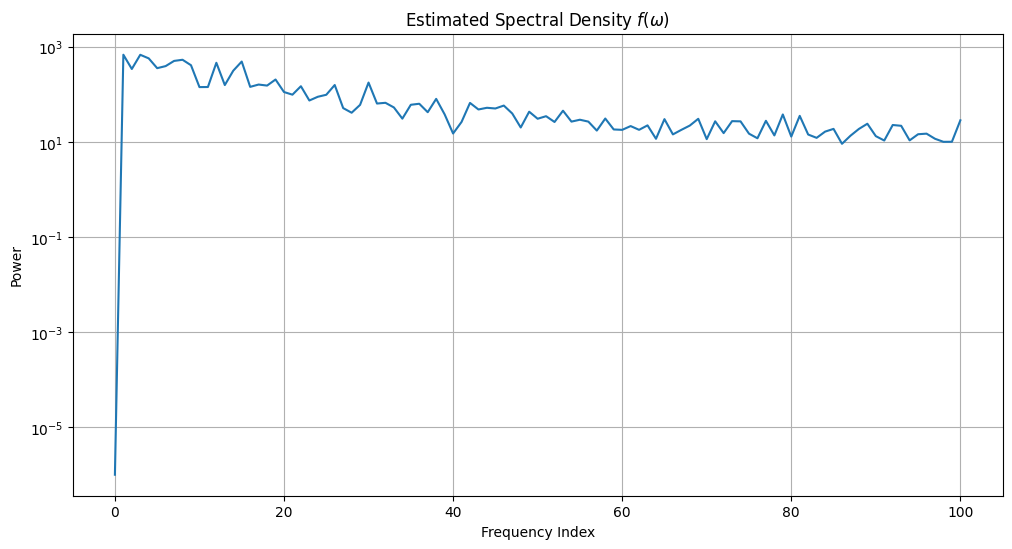

In [8]:
plt.semilogy(estimator.spectral_density)
plt.title("Estimated Spectral Density $f(\omega)$")
plt.xlabel("Frequency Index")
plt.ylabel("Power")
plt.grid(True, which="both", ls="-")
plt.show()

### Visualize Spatial Precision Matrix
The core claim is that $Q_{sp}$ is **sparse** and follows the graph structure.

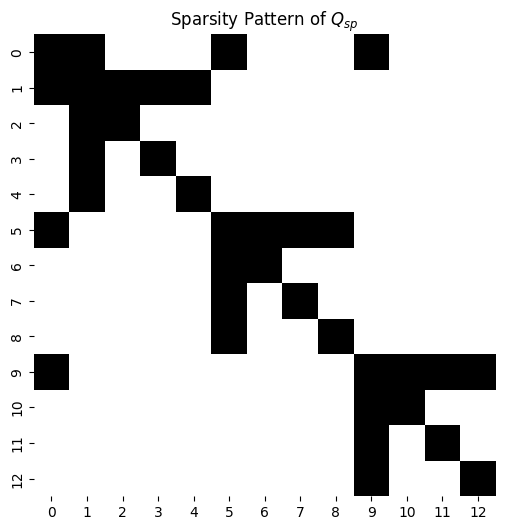

In [9]:
Q_dense = estimator.spatial_prec_matrix.toarray()
plt.figure(figsize=(8, 6))
sns.heatmap(np.abs(Q_dense) > 1e-4, cmap="Greys", cbar=False, square=True)
plt.title("Sparsity Pattern of $Q_{sp}$")
plt.show()

## 4. Reconciliation and Results

We apply the reconciliation: $\tilde{Y} = P_{sp} \hat{Y}$.

In [10]:
Y_tilde = estimator.reconcile(Y_hat)

# Verify Coherence
Y_tilde_bottom = Y_tilde[bottom_indices, :]
Y_tilde_sum = np.sum(Y_tilde_bottom, axis=0)
Y_tilde_top = Y_tilde[top_idx, :]

diff = np.abs(Y_tilde_top - Y_tilde_sum).max()
print(f"Max Incoherence after GS-GLS: {diff:.2e}")

Max Incoherence after GS-GLS: 0.00e+00


## 5. Performance Comparison

We compare the Mean Squared Error (MSE) of the Base Forecasts vs Reconciled Forecasts against the Ground Truth.

MSE Base:   51.7640
MSE GS-GLS: 23.2798
Improvement: 55.03%


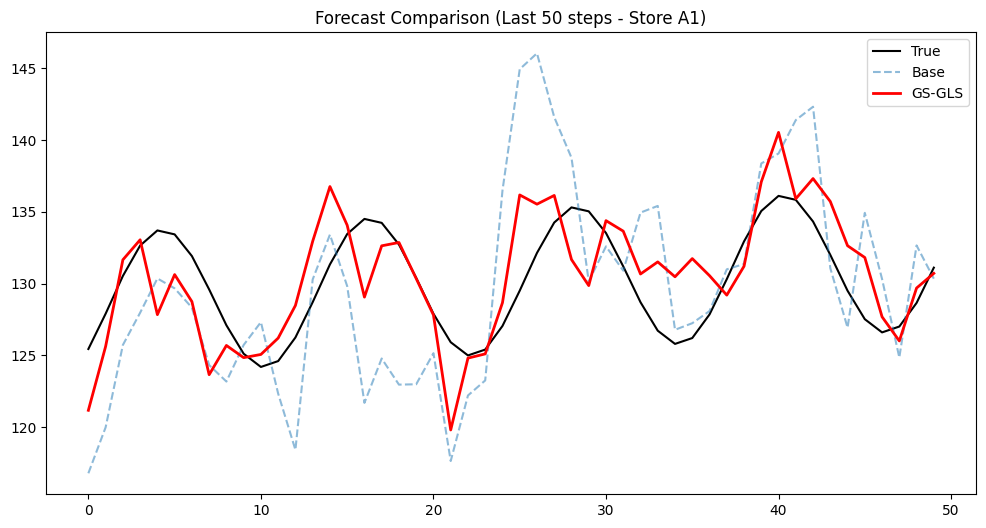

In [11]:
mse_base = np.mean((Y_hat - Y_true)**2)
mse_gsgls = np.mean((Y_tilde - Y_true)**2)

print(f"MSE Base:   {mse_base:.4f}")
print(f"MSE GS-GLS: {mse_gsgls:.4f}")
print(f"Improvement: {(1 - mse_gsgls/mse_base)*100:.2f}%")

# Visual comparison for one series
idx = h.node_to_idx['Store_A1']
plt.plot(Y_true[idx, -50:], label='True', color='black')
plt.plot(Y_hat[idx, -50:], label='Base', linestyle='--', alpha=0.5)
plt.plot(Y_tilde[idx, -50:], label='GS-GLS', color='red', linewidth=2)
plt.legend()
plt.title("Forecast Comparison (Last 50 steps - Store A1)")
plt.show()